# The code behind it: the empirical rule in code

*Part 1 · Lesson 9 · the code behind it  ·  data: Galton family heights (same as Lesson 9)*

*↩ A companion to [Lesson 9: The normal distribution & the empirical rule](09-normal-distribution.ipynb).*

**↩ Back:** [Lesson 9: The normal distribution & the empirical rule](09-normal-distribution.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset →](09-normal-distribution~another-dataset.ipynb)

**In Lesson 9 you watched real heights fall into the bell curve** and read the famous **68–95–99.7 rule**
off a chart — but `scipy.stats.norm` did the heavy lifting. This companion **opens the hood**: you'll
**standardize** the heights to z-scores by hand, **count** the empirical-rule fractions with boolean masks,
and even **build the normal-density formula yourself** — then check every piece against SciPy and watch it
print `match? True`.

Same Galton heights, same final picture — but the focus shifts from *what the bell curve means* to **how you
compute it in Python**. We'll go in the order a programmer actually works:

1. **The goal** — what we're building.
2. **The data in code** — load the same heights, look at their shape.
3. **Build it step by step** — z-scores by hand, the empirical-rule counts, and the normal density from its formula (each checked against SciPy).
4. **The idiom** — evaluating a formula *vectorized* across a grid vs. a slow Python loop, and "fraction of True."
5. **Refactor into a function** — wrap the counting up as your own reusable `empirical_rule()`.
6. **Now you code** — write-it-yourself exercises.
7. **What you learned** — the coding *and* the statistics.

You don't need Lesson 9 fresh in mind, but it helps. Run each grey cell with **Shift + Enter**, top to bottom.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

## 1) The goal

By the end of this notebook you'll have turned the bell curve's two famous results into a few lines of code
you could write from memory: a column of **z-scores** built by hand, the **68–95–99.7 fractions** counted
straight off the data, and the **normal-density formula** evaluated yourself and shown to match SciPy to the
last decimal. Nothing here needs new statistics — it's the Python *underneath* `scipy.stats.norm`.

The tools we'll use, and what each is for:

| Tool | What it is | What we use it for |
|---|---|---|
| **pandas** | tables (`DataFrame`) and columns (`Series`) | loading the CSV, the height column |
| **NumPy** | fast math on whole arrays at once | z-scores, the density formula on a grid |
| **matplotlib** | plotting | a density histogram with our own curve on top |
| **SciPy** | ready-made statistics | the *answer key* we check our from-scratch code against |

A single column of data is a **`Series`** — an array of values with an index. Almost everything below is "do
some arithmetic to the whole height column at once."

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

GALTON_URL = 'https://vincentarelbundock.github.io/Rdatasets/csv/HistData/GaltonFamilies.csv'
galton = sl.load_csv('galton.csv', url=GALTON_URL)
print(f'Loaded a {type(galton).__name__} with shape {galton.shape}  (rows, columns)')

Loaded a DataFrame with shape (934, 9)  (rows, columns)


## 2) The data in code

Same dataset as the core lesson: the heights of grown children from Francis Galton's 1880s family study.
Before any statistics, a programmer *interrogates the object* — how big is it, what are the columns, what is
the one we want?

- `.shape` → `(rows, columns)` as a tuple.
- `.columns` → the column names. We want **`childHeight`** (adult child height, in inches).
- `.head()` → the first few rows, to eyeball it.

We pull the `childHeight` column out as a `Series` and compute its **mean** $\mu$ (the curve's center) and
**standard deviation** $\sigma$ (its width). For a *sample* SD we pass `ddof=1` — "divide by $n-1$," not $n$;
more on that one line below.

In [2]:
print('shape  :', galton.shape)
print('columns:', list(galton.columns))
galton.head()

shape  : (934, 9)
columns: ['rownames', 'family', 'father', 'mother', 'midparentHeight', 'children', 'childNum', 'gender', 'childHeight']


,rownames,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,001,78.5,67.0,75.43,4,1,male,73.2
1,2,001,78.5,67.0,75.43,4,2,female,69.2
2,3,001,78.5,67.0,75.43,4,3,female,69.0
3,4,001,78.5,67.0,75.43,4,4,female,69.0
4,5,002,75.5,66.5,73.66,4,1,male,73.5


In [3]:
heights = galton['childHeight']          # the column we'll study — adult child height, in inches
print('heights is a', type(heights).__name__, 'of', len(heights), 'values; first 5:')
print(heights.head().to_list())

mu = heights.mean()                      # the curve's CENTER
sd = heights.std(ddof=1)                 # the curve's WIDTH (ddof=1 -> divide by n-1, the SAMPLE SD)
print(f'\nn   = {len(heights)} children')
print(f'mean (mu)               = {mu:.4f} inches')
print(f'standard deviation (sd) = {sd:.4f} inches')
print("(ddof=1 is how pandas/numpy say 'divide by n-1' for a sample. numpy's default is ddof=0 -> divide")
print(" by n -> a hair too small. We pass ddof=1 once here and reuse mu and sd everywhere below.)")

heights is a Series of 934 values; first 5:
[73.2, 69.2, 69.0, 69.0, 73.5]

n   = 934 children
mean (mu)               = 66.7459 inches
standard deviation (sd) = 3.5793 inches
(ddof=1 is how pandas/numpy say 'divide by n-1' for a sample. numpy's default is ddof=0 -> divide
 by n -> a hair too small. We pass ddof=1 once here and reuse mu and sd everywhere below.)


## 3) Build it step by step

Now the heart of it. Each piece is a short formula we'll write in NumPy and then check against SciPy with
`np.isclose` / `np.allclose` — when it prints `match? True`, the bell curve is no longer a mystery box.

### Standardize: turn heights into z-scores

A **z-score** says "how many SDs from the mean": $z = (x - \bar{x}) / s$. Because subtraction and division
work element-by-element, the *entire* column of z-scores is **one expression** — no loop over children. A
correct standardization always has mean $\approx 0$ and SD $= 1$; we check both.

In [4]:
z = (heights - mu) / sd                   # 934 z-scores in one vectorized line
print('first 5 z-scores:', np.round(z.head().to_numpy(), 3))
print(f'mean of z (should be ~0): {z.mean():.2e}')
print(f'SD of z   (should be  1): {z.std(ddof=1):.6f}')
print('match?', np.isclose(z.mean(), 0, atol=1e-9), np.isclose(z.std(ddof=1), 1.0))

first 5 z-scores: [1.803 0.686 0.63  0.63  1.887]
mean of z (should be ~0): 2.27e-15
SD of z   (should be  1): 1.000000
match? True True


### The empirical rule, by counting

The famous rule says that for a normal curve $\approx 68\% / 95\% / 99.7\%$ of values fall within
$1 / 2 / 3$ SDs of the mean. We don't have to *trust* it — we can **count**. The idiom: `z.abs() < 1` is a
column of `True`/`False`, and **the mean of a True/False column is the fraction that are `True`**. Multiply
by 100 for a percentage. We line our counted fractions up against the textbook numbers.

In [5]:
print(f"{'band':<12}{'data (counted)':>16}{'textbook':>12}")
print('-' * 40)
textbook = {1: 68.0, 2: 95.0, 3: 99.7}
observed = {}
for k in (1, 2, 3):
    pct = (z.abs() < k).mean() * 100      # fraction of True -> percentage within k SDs
    observed[k] = pct
    print(f"within {k} SD {pct:>14.1f}% {textbook[k]:>10.1f}%")
print("\n(z.abs() < k) is a True/False column; its .mean() is the share of True. The 2- and 3-SD bands")
print("land almost exactly on 95 / 99.7; the 1-SD band comes in a few points under 68 -- a reminder the")
print("empirical rule is an APPROXIMATION and real data is never perfectly normal.")

band          data (counted)    textbook
----------------------------------------
within 1 SD           62.4%       68.0%
within 2 SD           97.6%       95.0%
within 3 SD           99.7%       99.7%

(z.abs() < k) is a True/False column; its .mean() is the share of True. The 2- and 3-SD bands
land almost exactly on 95 / 99.7; the 1-SD band comes in a few points under 68 -- a reminder the
empirical rule is an APPROXIMATION and real data is never perfectly normal.


### The normal density, from its formula

The height of the bell curve at any value $x$ comes from one formula:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\; e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}
       = \frac{1}{\sigma\sqrt{2\pi}}\; e^{-\frac{(x-\mu)^2}{2\sigma^2}}.$$

We'll write it as a function and evaluate it **vectorized** on a grid of x-values — one call returns the whole
curve. Then the real test: does our hand-built `normal_pdf` agree with `scipy.stats.norm.pdf`? We check the
entire grid at once with `np.allclose`.

In [6]:
def normal_pdf(x, mu, sigma):
    '''The normal density f(x), straight from the formula. Works on a number or a whole array.'''
    return 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

xs = np.linspace(heights.min(), heights.max(), 200)   # 200 x-values from 56" to 79"
mine = normal_pdf(xs, mu, sd)                          # OUR curve — one vectorized call
scipy_curve = stats.norm.pdf(xs, mu, sd)               # SciPy's curve — the answer key

print('xs grid:', f'{len(xs)} points from {xs.min():.0f}" to {xs.max():.0f}"')
print('our normal_pdf, first 3 values :', np.round(mine[:3], 5))
print('scipy.norm.pdf, first 3 values :', np.round(scipy_curve[:3], 5))
print('match? (whole grid)            :', np.allclose(mine, scipy_curve))

xs grid: 200 points from 56" to 79"
our normal_pdf, first 3 values : [0.00123 0.00135 0.00149]
scipy.norm.pdf, first 3 values : [0.00123 0.00135 0.00149]
match? (whole grid)            : True


### Overlay it: does our curve hug the bars?

To compare a histogram of real heights with a *density* curve, the bar **areas** must add up to 1 — that's
what `density=True` does. Then our fitted `normal_pdf` can be drawn straight on top, on the same vertical
scale. If the red curve hugs the blue bars, these heights really are close to normal.

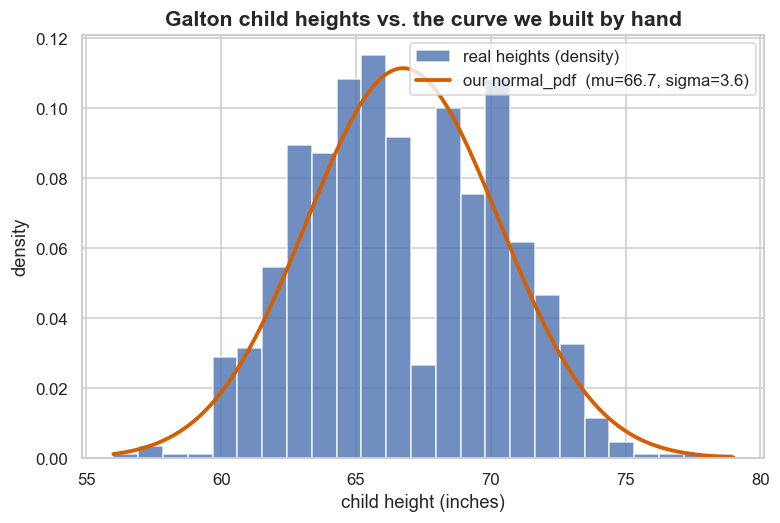

The hand-built red curve hugs the blue bars -> these heights are very nearly normal.


In [7]:
fig, ax = plt.subplots()
ax.hist(heights, bins=25, density=True, color='#4c72b0',
        edgecolor='white', alpha=0.8, label='real heights (density)')
ax.plot(xs, normal_pdf(xs, mu, sd), color='#D55E00', lw=2.5,
        label=f'our normal_pdf  (mu={mu:.1f}, sigma={sd:.1f})')
ax.set_xlabel('child height (inches)'); ax.set_ylabel('density')
ax.set_title('Galton child heights vs. the curve we built by hand')
ax.legend(); plt.show()
print('The hand-built red curve hugs the blue bars -> these heights are very nearly normal.')

### From z to a *probability*

Where do the textbook 68 / 95 / 99.7 numbers come from? The **CDF** — `stats.norm.cdf(z)` is the area under
the standard normal curve to the *left* of `z`. The fraction within $\pm k$ SDs is the area between $-k$ and
$+k$: `cdf(k) - cdf(-k)`. These are the *theoretical* targets our counted fractions above were chasing.

In [8]:
print(f"{'band':<12}{'theory (CDF)':>16}{'we counted':>14}")
print('-' * 42)
for k in (1, 2, 3):
    theory_pct = (stats.norm.cdf(k) - stats.norm.cdf(-k)) * 100
    print(f"within {k} SD {theory_pct:>14.4f}% {observed[k]:>12.1f}%")
print("\nThe theory column is where '68 / 95 / 99.7' actually comes from:")
print(f"  cdf(1)-cdf(-1) = {(stats.norm.cdf(1)-stats.norm.cdf(-1))*100:.2f}%  -> 'about 68%'")
print(f"  cdf(2)-cdf(-2) = {(stats.norm.cdf(2)-stats.norm.cdf(-2))*100:.2f}%  -> 'about 95%'")
print(f"  cdf(3)-cdf(-3) = {(stats.norm.cdf(3)-stats.norm.cdf(-3))*100:.2f}%  -> 'about 99.7%'")

band            theory (CDF)    we counted
------------------------------------------
within 1 SD        68.2689%         62.4%
within 2 SD        95.4500%         97.6%
within 3 SD        99.7300%         99.7%

The theory column is where '68 / 95 / 99.7' actually comes from:
  cdf(1)-cdf(-1) = 68.27%  -> 'about 68%'
  cdf(2)-cdf(-2) = 95.45%  -> 'about 95%'
  cdf(3)-cdf(-3) = 99.73%  -> 'about 99.7%'


## 4) The idiom — vectorized vs. a loop, and "fraction of True"

### Why we evaluated the formula in one call

We got the whole 200-point curve from `normal_pdf(xs, mu, sd)` — a *single* call, because the arithmetic
inside (`(x - mu) ** 2`, `np.exp(...)`) runs on the entire array at once. You *could* loop over the grid
instead; it gives the identical curve but is slower and noisier to read. Compare the two.

In [9]:
# The loop way (how you might first think of it):
mine_loop = np.array([normal_pdf(xi, mu, sd) for xi in xs])

# The vectorized way (what NumPy is for):
mine_vec = normal_pdf(xs, mu, sd)

print('same curve either way?', np.allclose(mine_loop, mine_vec))

# Time both on a bigger grid so the difference is visible.
import time
big_grid = np.linspace(heights.min(), heights.max(), 1_000_000)

t0 = time.perf_counter()
loop_out = np.array([normal_pdf(xi, mu, sd) for xi in big_grid])
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
vec_out = normal_pdf(big_grid, mu, sd)
t_vec = time.perf_counter() - t0

print(f'\nEvaluating the density at 1,000,000 points:')
print(f'  Python loop      : {t_loop*1000:7.1f} ms')
print(f'  vectorized (one call): {t_vec*1000:7.1f} ms')
print(f'  vectorized is roughly {t_loop/max(t_vec,1e-9):.0f}x faster -- and it is one short line.')

same curve either way? True



Evaluating the density at 1,000,000 points:
  Python loop      :   827.6 ms
  vectorized (one call):    13.1 ms
  vectorized is roughly 63x faster -- and it is one short line.


### "Fraction of True" is the workhorse

The empirical-rule counts used the single most useful one-liner in this lesson: a comparison makes a
True/False column, and its `.mean()` is the proportion that are `True`. It answers *any* "what share of the
data satisfies this condition?" question, no loop and no counter variable.

In [10]:
mask = z.abs() < 1                        # a True/False column, one per child
print('first 8 True/False:', mask.head(8).to_list())
print(f'.sum()  = {mask.sum()}   (how many are within 1 SD)')
print(f'.mean() = {mask.mean():.4f}   (the FRACTION within 1 SD -> {mask.mean()*100:.1f}%)')
print('That .mean()-of-a-mask trick is exactly what powered the 68/95/99.7 counts above.')

first 8 True/False: [False, True, True, True, False, False, True, True]
.sum()  = 583   (how many are within 1 SD)
.mean() = 0.6242   (the FRACTION within 1 SD -> 62.4%)
That .mean()-of-a-mask trick is exactly what powered the 68/95/99.7 counts above.


## 5) Refactor into a reusable function

You wrote the same "count within $k$ SDs" loop once already. The programmer's reflex is to **wrap repeated
work in a function**: name it, give it an input, `return` the result. Then "run the empirical rule" is one
call you can reuse on *any* numeric column — the full data, a subgroup, or an entirely different variable.

In [11]:
def empirical_rule(series):
    '''Return the observed % of values within 1, 2 and 3 SDs of the mean for a numeric Series.'''
    s = series.dropna()
    m = s.mean()
    sigma = s.std(ddof=1)               # ddof=1 -> sample SD, same choice as Section 2
    zs = (s - m) / sigma
    return {f'within_{k}_SD': round((zs.abs() < k).mean() * 100, 1) for k in (1, 2, 3)}

print('all children :', empirical_rule(heights))

# Reuse it on subgroups -- boys and girls separately -- with no copy-pasted formula:
for grp in ['male', 'female']:
    sub = galton[galton['gender'] == grp]['childHeight']
    print(f'{grp:13}: n={len(sub)}  ', empirical_rule(sub))

all children : {'within_1_SD': np.float64(62.4), 'within_2_SD': np.float64(97.6), 'within_3_SD': np.float64(99.7)}
male         : n=481   {'within_1_SD': np.float64(66.1), 'within_2_SD': np.float64(96.9), 'within_3_SD': np.float64(99.4)}
female       : n=453   {'within_1_SD': np.float64(70.4), 'within_2_SD': np.float64(95.6), 'within_3_SD': np.float64(99.3)}


A function is a contract: *give me a column, I'll give you its three empirical-rule percentages.* Once it's
correct you stop thinking about z-scores and masks and start thinking in **columns and summaries** — the leap
from "writing statistics" to "doing statistics in code." Notice each subgroup is its *own* near-normal bell,
so the rule holds inside each one too.

## 6) Now you code

Write the code yourself. Add a new cell (the **+** button in the toolbar) and try each — predict the answer
before you run it.

1. **A standalone z-score function.** Write `to_z(series)` that returns `(series - series.mean()) / series.std(ddof=1)`.
   Run it on `heights`, then confirm `to_z(heights).mean()` is ~0 and `to_z(heights).std(ddof=1)` is 1 with
   `np.isclose`. (You just rebuilt `scipy.stats.zscore` — check against `stats.zscore(heights, ddof=1)`.)

2. **One-sided tail by counting vs. theory.** What fraction of children are *taller than 70 inches*? Count it
   with `(heights > 70).mean() * 100`, then predict it from the curve: `z70 = (70 - mu) / sd` and
   `stats.norm.sf(z70) * 100` (the area to the *right* of `z70`). Do the count and the curve roughly agree?

3. **Check `normal_pdf` at the peak.** A normal curve is tallest at the mean. Evaluate your `normal_pdf(mu, mu, sd)`
   and compare it to `stats.norm.pdf(mu, mu, sd)` with `np.isclose` — and to the formula's peak value
   `1 / (sd * np.sqrt(2 * np.pi))`. All three should match.

4. **`empirical_rule` on a non-normal column.** Run `empirical_rule` on a skewed variable —
   `loans = sl.load_csv('loans.csv', url='https://www.openintro.org/data/csv/loans_full_schema.csv')` then
   `empirical_rule(loans['annual_income'])`. Are the percentages still near 68 / 95 / 99.7, or does the skew
   throw them off? (This shows *why* the rule needs a roughly-normal shape.)

## What you learned

**Coding**
- **Standardizing is one vectorized line:** `z = (s - s.mean()) / s.std(ddof=1)` turns a whole column into
  z-scores at once — no loop.
- **"Fraction of True"** — `(z.abs() < k).mean()` — answers any "what share satisfies this condition?" question;
  it's the trick behind the empirical-rule counts.
- **Write a formula as a function and evaluate it vectorized** across a grid (`normal_pdf(xs, mu, sd)`): one
  call returns the whole curve, far faster and cleaner than a Python loop.
- **Check from-scratch code against a trusted library** with `np.isclose` / `np.allclose` — when it prints
  `True`, you know your math is right.
- **Refactor repeated work into a function** with a clear input and a `return`, then reuse it on subgroups or
  a different column.

**Statistics (now demystified)**
- A **z-score** is just $(x-\bar{x})/s$; standardized data always has mean $\approx 0$ and SD $1$ (you checked it).
- The **empirical rule** isn't magic: counting Galton's heights gives about **62% / 98% / 99.7%** within
  $1/2/3$ SDs, close to the textbook **68 / 95 / 99.7** — and those textbook numbers are exactly
  `cdf(k) - cdf(-k)` (≈ 68.27% / 95.45% / 99.73%).
- The **normal density** is one formula, $\frac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/(2\sigma^2)}$; your hand-built
  `normal_pdf` matched `scipy.stats.norm.pdf` across the whole grid.
- Always pass **`ddof=1`** for a sample SD; numpy's default `ddof=0` divides by $n$ and comes out slightly small.

**Back to the core lesson** ([Lesson 9: The normal distribution & the empirical rule](09-normal-distribution.ipynb))
for the *meaning* of these numbers and where they lead — the Central Limit Theorem.

---

**↩ Back to the lesson:** [Lesson 9: The normal distribution & the empirical rule](09-normal-distribution.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset](09-normal-distribution~another-dataset.ipynb)